Modelo 2 - Regresión (Probabilidad de Churn 0.0 - 1.0)

Importar librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam as KerasAdam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

Cargar datos

In [2]:
df = pd.read_csv(r"C:\Users\Jesus\Downloads\ANN Regresión-20260529\customer_clean.csv")
X = df.drop('Churn', axis=1)
y = df['Churn']

SMOTE

In [3]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

Escalar

In [4]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res_scaled, y_res, test_size=0.2, random_state=42)

Modelo

In [6]:
model_reg = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_reg.compile(
    optimizer=KerasAdam(learning_rate=0.0005),
    loss='huber',
    metrics=['mae']
)

early_stop_reg = EarlyStopping(monitor='val_mae', patience=20, restore_best_weights=True)
reduce_lr_reg = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=7, min_lr=1e-6)

history_reg = model_reg.fit(
    X_train, y_train, epochs=300, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_reg, reduce_lr_reg], verbose=1
)

Epoch 1/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0724 - mae: 0.2783 - val_loss: 0.0670 - val_mae: 0.2838 - learning_rate: 5.0000e-04
Epoch 2/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0636 - mae: 0.2392 - val_loss: 0.0598 - val_mae: 0.2282 - learning_rate: 5.0000e-04
Epoch 3/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0602 - mae: 0.2346 - val_loss: 0.0596 - val_mae: 0.2198 - learning_rate: 5.0000e-04
Epoch 4/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0590 - mae: 0.2286 - val_loss: 0.0572 - val_mae: 0.2189 - learning_rate: 5.0000e-04
Epoch 5/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0567 - mae: 0.2213 - val_loss: 0.0564 - val_mae: 0.2112 - learning_rate: 5.0000e-04
Epoch 6/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0570 - mae: 0.2197 - val_loss: 0.0560 - val_mae: 0.2136 - learning_rate: 5.0000e-04
Epoch 7/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0562 - mae: 0.2221 - val_loss: 0.0563 - val_mae: 0

Evaluacion

In [7]:
loss_reg, mae_reg = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"Modelo Regresión - MAE: {mae_reg:.2f}")


Modelo Regresión - MAE: 0.19


visualizaciones

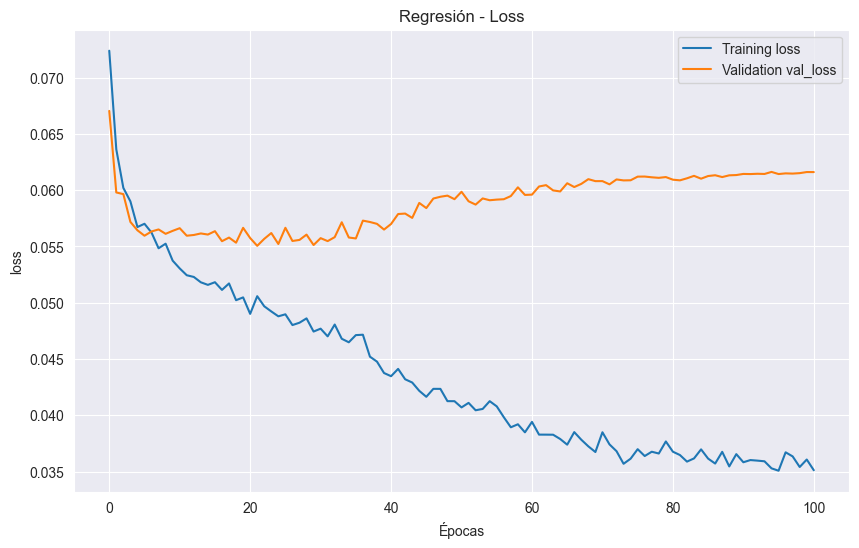

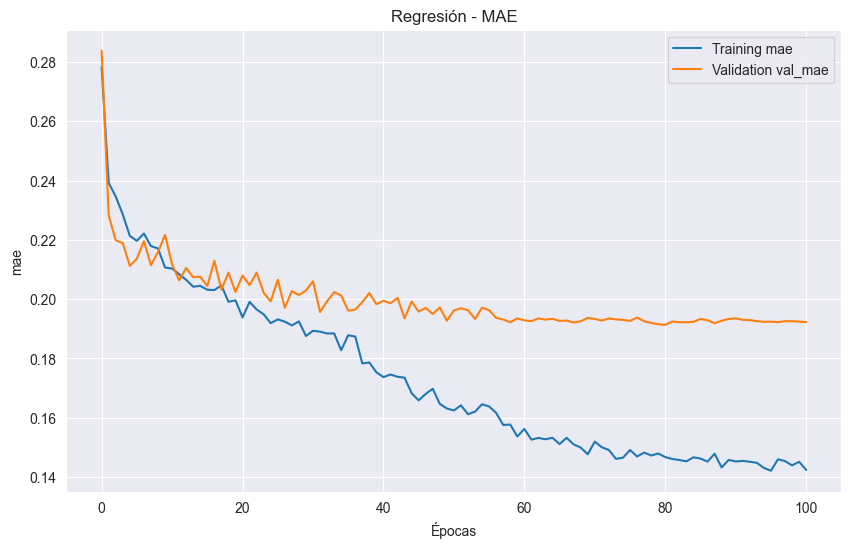

In [8]:
def plot_history(history, metric, val_metric, title):
    plt.figure(figsize=(10,6))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[val_metric], label=f'Validation {val_metric}')
    plt.title(title)
    plt.xlabel("Épocas")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

plot_history(history_reg, 'loss', 'val_loss', "Regresión - Loss")
plot_history(history_reg, 'mae', 'val_mae', "Regresión - MAE")



Segmentación por nivel de riesgo

In [9]:

y_pred_reg = model_reg.predict(X_test).flatten()

def segmentar_riesgo(prob):
    if prob < 0.33:
        return "Bajo"
    elif prob < 0.66:
        return "Medio"
    else:
        return "Alto"

segmentos = [segmentar_riesgo(p) for p in y_pred_reg]
import collections
print("Distribución por riesgo:", collections.Counter(segmentos))

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Distribución por riesgo: Counter({'Bajo': 949, 'Alto': 896, 'Medio': 221})


Guardar

In [10]:
model_reg.save("model_churn_reg.keras")
print("Modelo regresión guardado ")

Modelo regresión guardado 
